In [1]:
# Importing Libraries

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

In [2]:
# Reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# Config

HOT_DOG_CLASS = 55
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

EPOCHS_HEAD = 8
EPOCHS_FINE = 12

In [4]:
# Load Food-101 (as supervised)

(ds_train_raw, ds_valid_raw), ds_info = tfds.load(
    "food101",
    split=["train", "validation"],
    as_supervised=True,
    with_info=True,
    shuffle_files=True,
)

print(ds_info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.HBRPOI_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.HBRPOI_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='food101',
    full_name='food101/2.0.0',
    description="""
    This dataset consists of 101 food categories, with 101'000 images. For each class, 250 manually reviewed test images are provided as well as 750 training images. On purpose, the training images were not cleaned, and thus still contain some amount of noise. This comes mostly in the form of intense colors and sometimes wrong labels. All images were rescaled to have a maximum side length of 512 pixels.
    """,
    homepage='https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/',
    data_dir='/root/tensorflow_datasets/food101/2.0.0',
    file_format=tfrecord,
    download_size=4.65 GiB,
    dataset_size=4.77 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=101

Some binary-labeled samples:


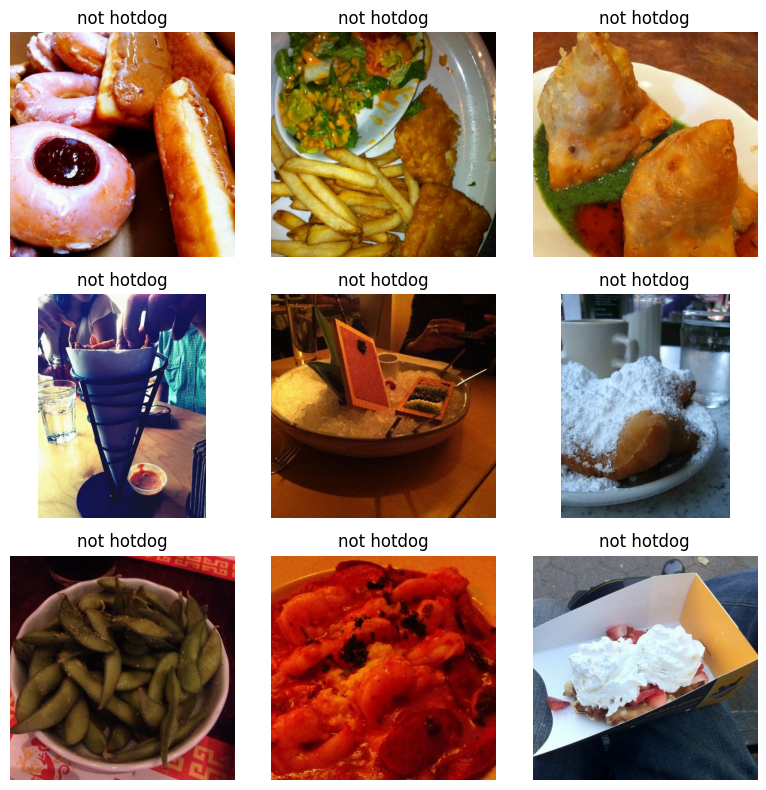

In [5]:
# Preprocessing

def to_hotdog_label(image, label):
    y = tf.cast(tf.equal(label, HOT_DOG_CLASS), tf.int32)
    return image, y

def preprocess(image, label):
    """
    Resize and cast to float32.
    We keep values in [0, 255] here; model preprocessing handles normalization.
    """
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE), antialias=True)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)

# Convert labels to binary first
ds_train_bin = ds_train_raw.map(to_hotdog_label, num_parallel_calls=AUTOTUNE)
ds_valid_bin = ds_valid_raw.map(to_hotdog_label, num_parallel_calls=AUTOTUNE)

# Show examples
def show_binary_examples(dataset, n=9):
    plt.figure(figsize=(8, 8))
    for i, (img, y) in enumerate(dataset.take(n)):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(img.numpy().astype(np.uint8))
        plt.title("hotdog" if int(y.numpy()) == 1 else "not hotdog")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

print("Some binary-labeled samples:")
show_binary_examples(ds_train_bin, n=9)

In [6]:
# Balance datasets

train_hot = ds_train_bin.filter(lambda x, y: tf.equal(y, 1))
train_not = ds_train_bin.filter(lambda x, y: tf.equal(y, 0))

valid_hot = ds_valid_bin.filter(lambda x, y: tf.equal(y, 1))
valid_not = ds_valid_bin.filter(lambda x, y: tf.equal(y, 0))

# Shuffle + repeat so sampling doesn't run out
train_hot = train_hot.shuffle(2000, seed=SEED, reshuffle_each_iteration=True).repeat()
train_not = train_not.shuffle(2000, seed=SEED, reshuffle_each_iteration=True).repeat()

valid_hot = valid_hot.repeat()
valid_not = valid_not.repeat()

# Balanced sampling
train_balanced = tf.data.Dataset.sample_from_datasets(
    [train_hot, train_not],
    weights=[0.5, 0.5],
    seed=SEED
)

valid_balanced = tf.data.Dataset.sample_from_datasets(
    [valid_hot, valid_not],
    weights=[0.5, 0.5],
    seed=SEED
)

STEPS_PER_EPOCH = 300
VAL_STEPS = 80

# Apply preprocessing + batching
train_ds = (
    train_balanced
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

valid_ds = (
    valid_balanced
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [7]:
# Model: Transfer Learning (EfficientNetV2B0)

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.12),
        tf.keras.layers.RandomZoom(0.15),
        tf.keras.layers.RandomContrast(0.15),
        tf.keras.layers.RandomTranslation(0.05, 0.05),
    ],
    name="augmentation",
)

base_model = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False  # phase 1

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
# EfficientNetV2 preprocessing
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,920,593 (22.59 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [8]:
# Callbacks

ckpt_path = "hotdog_not_hotdog_best.keras"
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_path, monitor="val_auc", mode="max", save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=4, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6, verbose=1
    ),
]

In [9]:
# Train head

history_head = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_HEAD,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VAL_STEPS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/8
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8420 - auc: 0.9199 - loss: 0.3732 - precision: 0.8460 - recall: 0.8241
Epoch 1: val_auc improved from -inf to 0.99424, saving model to hotdog_not_hotdog_best.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 1962s 6s/step - accuracy: 0.8421 - auc: 0.9200 - loss: 0.3729 - precision: 0.8461 - recall: 0.8243 - val_accuracy: 0.9414 - val_auc: 0.9942 - val_loss: 0.1548 - val_precision: 0.9020 - val_recall: 0.9881 - learning_rate: 0.0010
Epoch 2/8
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9122 - auc: 0.9728 - loss: 0.2176 - precision: 0.9211 - recall: 0.9041
Epoch 2: val_auc did not improve from 0.99424
300/300 ━━━━━━━━━━━━━━━━━━━━ 1650s 5s/step - accuracy: 0.9122 - auc: 0.9728 - loss: 0.2176 - precision: 0.9211 - recall: 0.9041 - val_accuracy: 0.9512 - val_auc: 0.9941 - val_loss: 0.1302 - val_precision: 0.9250 - val_recall: 0.9801 - learning_rate: 0.0010
Epoch 3/8
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9121 - auc: 0

In [10]:
# Fine-tune

base_model.trainable = True

UNFREEZE_LAST_N = 60
for layer in base_model.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ],
)

history_fine = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=EPOCHS_FINE,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VAL_STEPS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/12
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8676 - auc: 0.9493 - loss: 0.3097 - precision: 0.8944 - recall: 0.8243
Epoch 1: val_auc did not improve from 0.99514
300/300 ━━━━━━━━━━━━━━━━━━━━ 2302s 7s/step - accuracy: 0.8676 - auc: 0.9493 - loss: 0.3096 - precision: 0.8945 - recall: 0.8244 - val_accuracy: 0.9613 - val_auc: 0.9940 - val_loss: 0.1376 - val_precision: 0.9482 - val_recall: 0.9746 - learning_rate: 1.0000e-05
Epoch 2/12
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8917 - auc: 0.9628 - loss: 0.2649 - precision: 0.9175 - recall: 0.8638
Epoch 2: val_auc did not improve from 0.99514
300/300 ━━━━━━━━━━━━━━━━━━━━ 1898s 6s/step - accuracy: 0.8917 - auc: 0.9629 - loss: 0.2648 - precision: 0.9174 - recall: 0.8638 - val_accuracy: 0.9664 - val_auc: 0.9949 - val_loss: 0.1184 - val_precision: 0.9564 - val_recall: 0.9762 - learning_rate: 1.0000e-05
Epoch 3/12
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9083 - auc: 0.9717 - loss: 0.2291 - precision: 0.

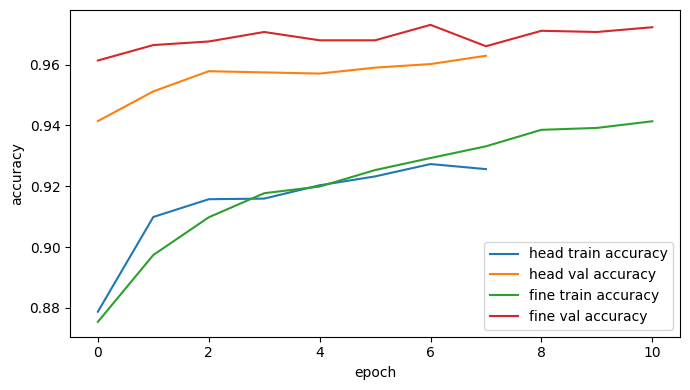

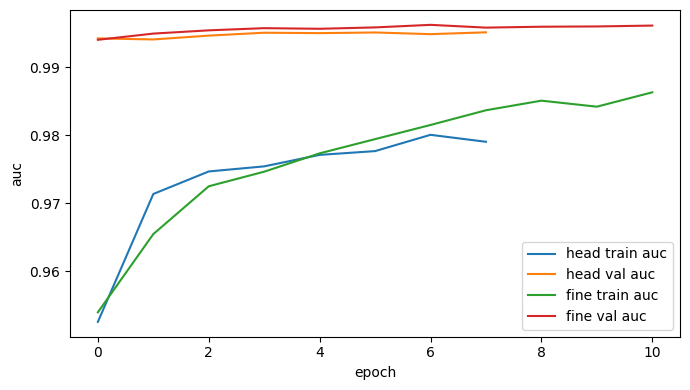

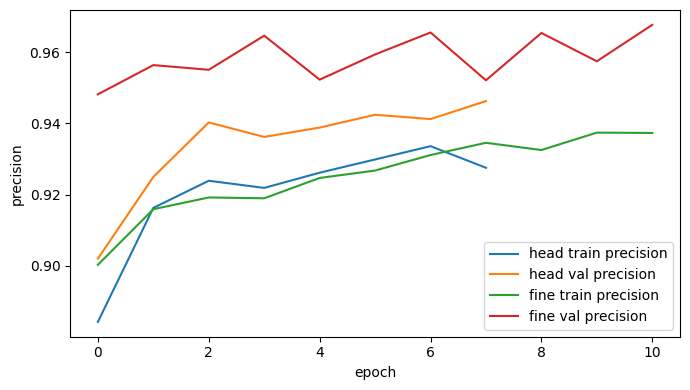

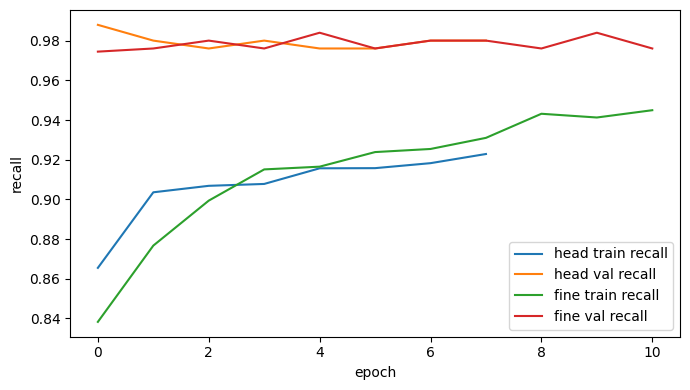

In [11]:
# Plot training curves


def plot_metric(histories, metric):
    plt.figure(figsize=(7, 4))
    for h, name in histories:
        if metric in h.history:
            plt.plot(h.history[metric], label=f"{name} train {metric}")
        val_key = "val_" + metric
        if val_key in h.history:
            plt.plot(h.history[val_key], label=f"{name} val {metric}")
    plt.xlabel("epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric([(history_head, "head"), (history_fine, "fine")], "accuracy")
plot_metric([(history_head, "head"), (history_fine, "fine")], "auc")
plot_metric([(history_head, "head"), (history_fine, "fine")], "precision")
plot_metric([(history_head, "head"), (history_fine, "fine")], "recall")

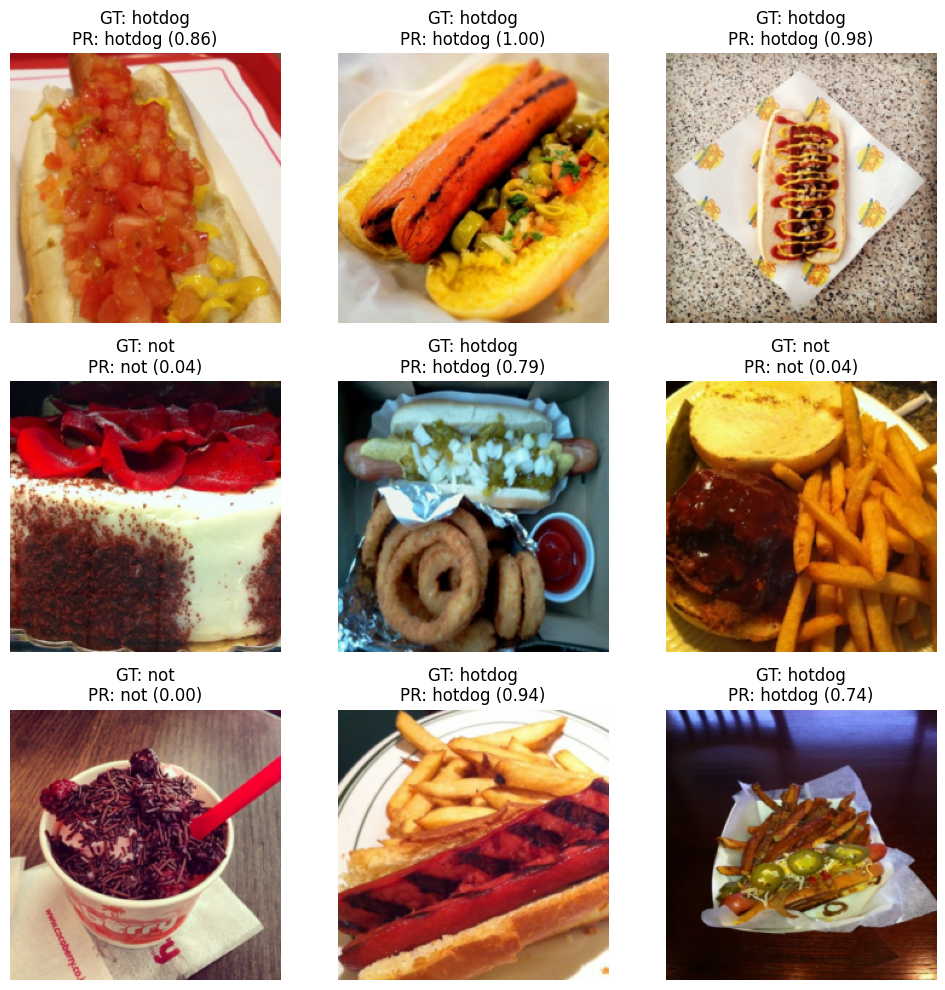

In [12]:
# Visualize predictions on a validation batch

model.load_weights(ckpt_path)

for images, labels in valid_ds.take(1):
    probs = model.predict(images, verbose=0).reshape(-1)
    preds = (probs >= 0.5).astype(int)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(tf.cast(tf.clip_by_value(images[i], 0, 255), tf.uint8))
    gt = "hotdog" if int(labels[i].numpy()) == 1 else "not"
    pr = "hotdog" if preds[i] == 1 else "not"
    plt.title(f"GT: {gt}\nPR: {pr} ({probs[i]:.2f})")
    plt.axis("off")
plt.tight_layout()
plt.show()